<a href="https://colab.research.google.com/github/hasnaa-aboelhana/depi-graduation-project/blob/main/resnet152v2_eurosat_v3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# Define a persistent folder on Drive to save everything
DRIVE_SAVE_DIR = '/content/drive/MyDrive/EuroSAT_Models'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

Mounted at /content/drive


# Land-Cover Classification with EuroSAT — ResNet152V2 (v3.1 — Auto-Resume)

This notebook trains and evaluates a **ResNet152V2** model on the EuroSAT RGB
dataset for land-cover classification (10 classes, 64x64 satellite patches).

It is one model in a larger comparison study (ResNet50, ResNet50V2,
ResNet152V2, VGG16, VGG19, etc.). Each model lives in its own self-contained
notebook so it can be run and graded independently; this one covers
**ResNet152V2 only**.

**Pipeline:**
1. Download the dataset (via `kagglehub`)
2. Split into train/test sets and set up data generators
3. Build a ResNet152V2-based classifier (ImageNet weights + custom head)
4. Train in two stages — frozen backbone, then full fine-tuning
5. Evaluate on the test set and save the trained model

**v2 improvements:** This version automatically saves progress after
every epoch and resumes from the last checkpoint if the Colab runtime
crashes or disconnects. Just re-run all cells — no manual changes needed.

**Reference:** Helber et al., *EuroSAT: A Novel Dataset and Deep Learning
Benchmark for Land Use and Land Cover Classification*, IEEE JSTARS, 2019.

## 1. Setup

Import the libraries used throughout this notebook.

In [ ]:
import os
import re
import shutil

from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    f1_score,
    fbeta_score,
    accuracy_score,
)

import tensorflow as tf
from keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.regularizers import l2
from keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from keras.optimizers import Adam
from keras.optimizers.schedules import CosineDecayRestarts
from keras.applications import ResNet152V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**GPU configuration.** If a GPU is available, restrict TensorFlow to the
first one and enable soft device placement so ops fall back to CPU when
needed.

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPU")
    except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(e)

tf.config.set_soft_device_placement(True)

1 Physical GPUs, 1 Logical GPU


## 2. Dataset

Download the EuroSAT RGB dataset from Kaggle via `kagglehub`. The helper
below downloads the dataset (skipping the download if it's already cached
locally) and locates the directory that directly contains the 10 class
sub-folders, regardless of the exact folder layout inside the archive.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nilesh789/eurosat-rgb")
print("Path to dataset files:", path)

100%|██████████| 89.6M/89.6M [00:00<00:00, 144MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nilesh789/eurosat-rgb/versions/1


In [ ]:
# Locate the folder that directly contains the 10 class sub-directories
# (the archive layout can nest the images one level deeper, e.g. .../2750).
EXPECTED_CLASSES = {
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake',
}

DATASET = None
for root, dirs, _ in os.walk(path):
    if EXPECTED_CLASSES.issubset(set(dirs)):
        DATASET = root
        break

if DATASET is None:
    raise FileNotFoundError(
        f"Could not locate the EuroSAT class folders under: {path}"
    )

LABELS = sorted(os.listdir(DATASET))
print("Dataset directory:", DATASET)
print("Classes found:", LABELS)

Dataset directory: /root/.cache/kagglehub/datasets/nilesh789/eurosat-rgb/versions/1/2750
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 3. Train / Test Split

Hold out 20% of the images for testing using a stratified split, so the
class proportions are preserved in both subsets. Images are physically
copied into `training/` and `testing/` folders (each with one sub-folder
per class) so Keras's `ImageDataGenerator.flow_from_directory` can be used
directly.

In [ ]:
TRAIN_DIR = 'training'
TEST_DIR = 'testing'
BATCH_SIZE = 64
NUM_CLASSES = len(LABELS)
INPUT_SHAPE = (64, 64, 3)
CLASS_MODE = 'categorical'

# Check if the train/test split already exists (idempotent for Colab restarts)
_train_count = sum(len(f) for _, _, f in os.walk(TRAIN_DIR)) if os.path.exists(TRAIN_DIR) else 0
_test_count = sum(len(f) for _, _, f in os.walk(TEST_DIR)) if os.path.exists(TEST_DIR) else 0
SPLIT_ALREADY_DONE = _train_count > 0 and _test_count > 0

if SPLIT_ALREADY_DONE:
    print(f"Existing split found: {_train_count} train / {_test_count} test images. Skipping re-split.")
else:
    # Clean up any leftover partial files to prevent data leakage
    for split_dir in (TRAIN_DIR, TEST_DIR):
        if os.path.exists(split_dir):
            shutil.rmtree(split_dir)

    # Create training and testing directories (with one sub-folder per class)
    for split_dir in (TRAIN_DIR, TEST_DIR):
        os.makedirs(split_dir, exist_ok=True)
        for label in LABELS:
            os.makedirs(os.path.join(split_dir, label), exist_ok=True)

In [ ]:
if not SPLIT_ALREADY_DONE:
    # Map every image path to its class label
    data = {}
    for label in LABELS:
        for img in os.listdir(os.path.join(DATASET, label)):
            data[os.path.join(DATASET, label, img)] = label

    X = pd.Series(list(data.keys()))
    y = pd.get_dummies(pd.Series(data.values()))

    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=69)

    # Perform the stratified split and copy files into TRAIN_DIR / TEST_DIR
    for train_idx, test_idx in split.split(X, y):

        train_paths = X[train_idx]
        test_paths = X[test_idx]

        new_train_paths = [
            p.replace(DATASET, TRAIN_DIR) for p in train_paths
        ]
        new_test_paths = [
            p.replace(DATASET, TEST_DIR) for p in test_paths
        ]

        train_path_map = list(zip(train_paths, new_train_paths))
        test_path_map = list(zip(test_paths, new_test_paths))

        print("Copying training files...")
        for src, dst in tqdm(train_path_map):
            if not os.path.exists(dst):
                shutil.copy(src, dst)

        print("Copying testing files...")
        for src, dst in tqdm(test_path_map):
            if not os.path.exists(dst):
                shutil.copy(src, dst)
else:
    print("Skipping file copy (split already exists).")

Copying training files...


100%|██████████| 21600/21600 [00:02<00:00, 9958.72it/s] 


Copying testing files...


100%|██████████| 5400/5400 [00:00<00:00, 10844.48it/s]


**Data generators.** The training generator applies on-the-fly data
augmentation (rotation, shifts, shear, zoom, flips) to reduce overfitting;
the test generator only rescales pixel values, since augmentation should
not be applied at evaluation time.

In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=360,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=10.0,
)

train_generator = train_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=True,
    seed=69,
)

# Test generator: preprocessing only, no augmentation, used for validation/evaluation
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=False,
    seed=69,
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
print(train_generator.class_indices)
np.save('class_indices', train_generator.class_indices)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


## 4. Helper Functions

Utility functions used to build the model, visualize training curves,
summarize evaluation metrics, and preview predictions.

- `compile_model` — builds a ResNet152V2 backbone (ImageNet weights) with a
  custom dense classification head, and freezes/unfreezes backbone layers
  as requested via `fine_tune`.
- `plot_history` — plots training/validation accuracy and loss curves.
- `display_results` — computes per-class precision/recall/F-score plus
  overall accuracy and F2-score, and returns a confusion matrix.
- `plot_predictions` — shows a grid of sample test images with predicted
  vs. true labels.

In [ ]:
def compile_model(cnn_base, input_shape, n_classes, optimizer, fine_tune=None):
    """Build and compile a ResNet152V2 classifier.

    Parameters
    ----------
    cnn_base : str
        Name of the backbone to use. Only 'ResNet152V2' is used in this
        notebook; the conditional structure is kept so the function stays
        consistent with the sibling notebooks for the other architectures.
    input_shape : tuple
        Shape of the input images, e.g. (64, 64, 3).
    n_classes : int
        Number of output classes.
    optimizer : keras.optimizers.Optimizer
        Optimizer instance to compile the model with.
    fine_tune : int or None
        If None, all backbone layers are frozen (only the new head trains).
        If an int, backbone layers from that index onward are unfrozen for
        end-to-end fine-tuning (0 unfreezes the entire backbone).
    """
    if cnn_base == 'ResNet152V2':
        conv_base = ResNet152V2(
            include_top=False,
            weights='imagenet',
            input_shape=input_shape,
        )
    else:
        raise ValueError(f"Unsupported cnn_base for this notebook: {cnn_base}")

    top_model = conv_base.output
    top_model = GlobalAveragePooling2D()(top_model)
    top_model = Dropout(0.5)(top_model)

    output_layer = Dense(
        n_classes, activation='softmax', kernel_regularizer=l2(0.01)
    )(top_model)

    model = Model(inputs=conv_base.input, outputs=output_layer)

    if isinstance(fine_tune, int):
        for layer in conv_base.layers[fine_tune:]:
            layer.trainable = True
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy'],
    )

    return model


def plot_history(history):
    """Plot training/validation accuracy and loss curves."""
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(acc)
    plt.plot(val_acc)
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(loss)
    plt.plot(val_loss)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    plt.show()


def display_results(y_true, y_preds, class_labels):
    """Print accuracy/F2-score and return per-class metrics + confusion matrix."""
    results = pd.DataFrame(
        precision_recall_fscore_support(y_true, y_preds),
        columns=class_labels,
    ).T
    results.rename(
        columns={0: 'Precision', 1: 'Recall', 2: 'F-Score', 3: 'Support'},
        inplace=True,
    )

    conf_mat = pd.DataFrame(
        confusion_matrix(y_true, y_preds),
        columns=class_labels,
        index=class_labels,
    )

    f2 = fbeta_score(y_true, y_preds, beta=2, average='micro')
    macro_f1 = f1_score(y_true, y_preds, average='macro')
    accuracy = accuracy_score(y_true, y_preds)
    print(f"Accuracy: {accuracy}")
    print(f"Macro F1 Score: {macro_f1}")
    print(f"Global F2 Score: {f2}")

    return results, conf_mat


def plot_predictions(y_true, y_preds, test_generator, class_indices):
    """Show a grid of test images with predicted vs. true class labels."""
    fig = plt.figure(figsize=(20, 10))
    for i, idx in enumerate(
        np.random.choice(test_generator.samples, size=20, replace=False)
    ):
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        image = np.squeeze(test_generator[idx])
        # Shifts the ResNet [-1, 1] pixel range back to a normal [0, 1] range for Matplotlib
        image_for_plot = (image + 1.0) / 2.0
        plt.imshow(image_for_plot)
        pred_idx = np.argmax(y_preds[idx])
        true_idx = y_true[idx]

        plt.tight_layout()
        ax.set_title(
            "{}
({})".format(class_indices[pred_idx], class_indices[true_idx]),
            color=("green" if pred_idx == true_idx else "red"),
        )


## 5. Training Configuration

Define per-stage file paths for checkpoints and CSV logs. Each training
stage saves its own best-weights checkpoint and a CSV log of all completed
epochs. On restart, the notebook reads the log to determine where to
resume from — no manual editing required.

In [ ]:
N_STEPS = len(train_generator)      # = ceil(samples / batch_size)
N_VAL_STEPS = len(test_generator)   # = ceil(samples / batch_size)

# --- File paths for resilient training (survive Colab restarts) ---

# Stage 1: Head-only training
HEAD_EPOCHS = 50
HEAD_CHECKPOINT = os.path.join(DRIVE_SAVE_DIR, 'resnet152v2_head.weights.best.keras')
HEAD_LOG = os.path.join(DRIVE_SAVE_DIR, 'resnet152v2_head_log.csv')
HEAD_DONE_FLAG = os.path.join(DRIVE_SAVE_DIR, '.resnet152v2_head_done')

# Stage 2: Full fine-tuning
FINETUNE_EPOCHS = 100
FINETUNE_CHECKPOINT = os.path.join(DRIVE_SAVE_DIR, 'resnet152v2_finetune.weights.best.keras')
FINETUNE_LOG = os.path.join(DRIVE_SAVE_DIR, 'resnet152v2_finetune_log.csv')
FINETUNE_DONE_FLAG = os.path.join(DRIVE_SAVE_DIR, '.resnet152v2_finetune_done')

print(f"Training steps/epoch: {N_STEPS}, Validation steps/epoch: {N_VAL_STEPS}")

# Mild targeted class balancing for classes with repeated confusion
TARGET_CLASS_WEIGHTS = {
    'Highway': 1.35,
    'River': 1.35,
    'HerbaceousVegetation': 1.20,
    'Pasture': 1.20,
    'PermanentCrop': 1.20,
}

class_weight = {
    idx: TARGET_CLASS_WEIGHTS.get(class_name, 1.0)
    for class_name, idx in train_generator.class_indices.items()
}

print('Class weights by class index:')
for class_name, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    print(f"  {idx}: {class_name} -> {class_weight[idx]}")

Training steps/epoch: 338, Validation steps/epoch: 85
Class weights by class index:
  0: AnnualCrop -> 1.0
  1: Forest -> 1.0
  2: HerbaceousVegetation -> 1.2
  3: Highway -> 1.35
  4: Industrial -> 1.0
  5: Pasture -> 1.2
  6: PermanentCrop -> 1.2
  7: Residential -> 1.0
  8: River -> 1.35
  9: SeaLake -> 1.0


## 6. ResNet152V2 Model

Training is done in two stages, a common transfer-learning recipe:

1. **Head-only training** — the ResNet152V2 backbone (pretrained on
   ImageNet) is frozen, and only the new dense classification head is
   trained with a relatively high learning rate.
2. **End-to-end fine-tuning** — the entire network is unfrozen and trained
   further at a much lower learning rate, using the best head-only weights
   as the starting point.

### 6.1 Build the model

In [ ]:
resnet152V2_model = compile_model(
    'ResNet152V2', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-2), fine_tune=None
)
resnet152V2_model.summary()

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 16, 16,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 16, 16,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 18, 18,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 16, 16,    │          0 │ conv2_block1_0_c

 Total params: 58,352,138 (222.60 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 58,331,648 (222.52 MB)

### 6.2 Stage 1 — Head-only training

Train only the classification head (backbone frozen). Training
automatically resumes from the last completed epoch if the runtime
restarts.

In [ ]:
# --- Stage 1: Head-only training (frozen backbone) ---
if os.path.exists(HEAD_DONE_FLAG):
    print(">> Stage 1 (head-only training) already completed. Skipping.")
    resnet152V2_model.load_weights(HEAD_CHECKPOINT)
else:
    head_resume_epoch = 0

    # Check for existing progress to resume from
    if os.path.exists(HEAD_LOG) and os.path.exists(HEAD_CHECKPOINT):
        try:
            df = pd.read_csv(HEAD_LOG)
            if not df.empty:
                head_resume_epoch = len(df)
                resnet152V2_model.load_weights(HEAD_CHECKPOINT)
                print(f">> Resuming head-only training from epoch {head_resume_epoch + 1}/{HEAD_EPOCHS}")
        except Exception as e:
            print(f"Error reading log ({e}). Starting from scratch.")
            head_resume_epoch = 0

    if head_resume_epoch == 0:
        print(">> Starting head-only training from scratch.")

    head_callbacks = [
        EarlyStopping(
            monitor='val_categorical_accuracy', patience=10,
            restore_best_weights=True, mode='max',
        ),
        ModelCheckpoint(
            filepath=HEAD_CHECKPOINT, monitor='val_categorical_accuracy',
            save_best_only=True, verbose=1,
        ),
        CSVLogger(HEAD_LOG, append=(head_resume_epoch > 0)),
    ]

    resnet152V2_history = resnet152V2_model.fit(
        train_generator,
        steps_per_epoch=N_STEPS,
        epochs=HEAD_EPOCHS,
        initial_epoch=head_resume_epoch,
        callbacks=head_callbacks,
        class_weight=class_weight,
        validation_data=test_generator,
        validation_steps=N_VAL_STEPS,
    )

    # Mark stage as complete
    with open(HEAD_DONE_FLAG, 'w') as f:
        f.write('done')
    print(">> Stage 1 (head-only training) complete.")

>> Starting head-only training from scratch.
Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - categorical_accuracy: 0.5997 - loss: 2.2138
Epoch 1: val_categorical_accuracy improved from None to 0.73778, saving model to /content/drive/MyDrive/EuroSAT_Models/resnet152v2_head.weights.best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EuroSAT_Models/resnet152v2_head.weights.best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 126s 286ms/step - categorical_accuracy: 0.6326 - loss: 2.2131 - val_categorical_accuracy: 0.7378 - val_loss: 1.7561
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - categorical_accuracy: 0.6376 - loss: 2.3680
Epoch 2: val_categorical_accuracy did not improve from 0.73778
338/338 ━━━━━━━━━━━━━━━━━━━━ 64s 190ms/step - categorical_accuracy: 0.6346 - loss: 2.3534 - val_categorical_accuracy: 0.7185 - val_loss: 1.8765
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - categorical_accuracy: 0.6400 - loss: 2.4427
Epoch 3: val_categorical_accuracy did n

### 6.3 Stage 2 — End-to-end fine-tuning

Unfreeze the entire backbone and continue training at a lower learning
rate. Automatically resumes from the last completed epoch if the runtime
restarts.

In [ ]:
# Load the Stage 1 (head-only) weights from Drive so we can skip Stage 1
resnet152v2_model.load_weights('/content/drive/MyDrive/EuroSAT_Models/resnet152v2_head.weights.best.keras')
print("Stage 1 weights loaded successfully! Ready for Stage 2.")

In [ ]:
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Unfreeze the backbone
base_model.trainable = True

# 2. Setup the Cosine Annealing Learning Rate
initial_learning_rate = 1e-4
lr_schedule = CosineDecayRestarts(
    initial_learning_rate=initial_learning_rate,
    first_decay_steps=10 * N_STEPS, # Decays over 10 epochs before restarting
    t_mul=2.0,
    m_mul=0.9,
    alpha=0.01 # Minimum lr floor
)

# 3. Recompile with the new scheduler
resnet152v2_model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# ==========================================
# 4. THE PLAN A UPGRADES (Callbacks)
# ==========================================

# Upgrade 1: Patience of 25 to survive the LR restarts, Auto-Restore turned ON
early_stop_2 = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

# Upgrade 2: Checkpoint A (Saves when the model is most CONFIDENT)
checkpoint_loss = ModelCheckpoint(
    '/content/drive/MyDrive/EuroSAT_Models/resnet152v2_finetune_best_loss.weights.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True
)

# Upgrade 3: Checkpoint B (Saves when the model gets the most CORRECT answers)
checkpoint_acc = ModelCheckpoint(
    '/content/drive/MyDrive/EuroSAT_Models/resnet152v2_finetune_best_acc.weights.keras',
    monitor='val_categorical_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True
)

print(">> Starting Stage 2: Full Fine-Tuning with extended patience...")
history_stage2 = resnet152v2_model.fit(
    train_generator,
    steps_per_epoch=N_STEPS,
    epochs=100, # Leave this high; EarlyStopping will safely stop it
    validation_data=test_generator,
    validation_steps=N_VAL_STEPS,
    callbacks=[early_stop_2, checkpoint_loss, checkpoint_acc],
    workers=2 # Keeps data loading stable
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


>> Starting fine-tuning from best head-only weights.
Epoch 1/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - categorical_accuracy: 0.6863 - loss: 2.1148
Epoch 1: val_categorical_accuracy improved from None to 0.90222, saving model to /content/drive/MyDrive/EuroSAT_Models/resnet152v2_finetune.weights.best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EuroSAT_Models/resnet152v2_finetune.weights.best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 319s 497ms/step - categorical_accuracy: 0.7958 - loss: 1.4709 - val_categorical_accuracy: 0.9022 - val_loss: 0.8889
Epoch 2/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - categorical_accuracy: 0.8990 - loss: 0.9361
Epoch 2: val_categorical_accuracy improved from 0.90222 to 0.92704, saving model to /content/drive/MyDrive/EuroSAT_Models/resnet152v2_finetune.weights.best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/EuroSAT_Models/resnet152v2_finetune.weights.best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 98s 290ms/step - categor

## 7. Training History

Plot the training/validation accuracy and loss curves for both stages,
loaded from the CSV log files (persistent across restarts).

--- Head-Only Training History ---


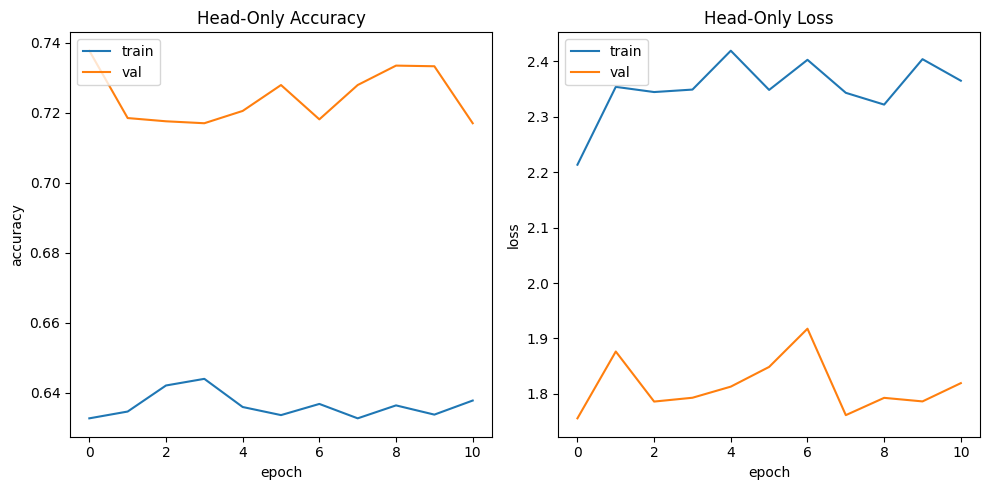


--- Fine-Tuning History ---


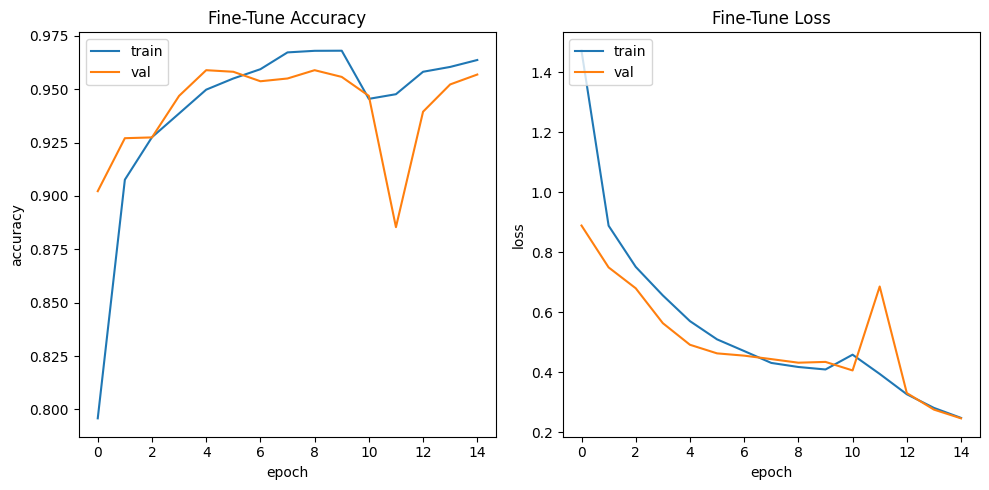

In [ ]:
# Plot training history from CSV logs (works across Colab restarts)

def plot_from_log(log_path, title_prefix=''):
    """Plot training/validation accuracy and loss from a CSV log file."""
    df = pd.read_csv(log_path)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['categorical_accuracy'], label='train')
    plt.plot(df['val_categorical_accuracy'], label='val')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.title(f'{title_prefix} Accuracy' if title_prefix else 'Accuracy')
    plt.legend(loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(df['loss'], label='train')
    plt.plot(df['val_loss'], label='val')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.title(f'{title_prefix} Loss' if title_prefix else 'Loss')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

if os.path.exists(HEAD_LOG):
    print("--- Head-Only Training History ---")
    plot_from_log(HEAD_LOG, 'Head-Only')

if os.path.exists(FINETUNE_LOG):
    print("\n--- Fine-Tuning History ---")
    plot_from_log(FINETUNE_LOG, 'Fine-Tune')

## 7. Evaluation

Load the best checkpoint and evaluate on the held-out test set: overall
accuracy/F2-score plus a per-class precision/recall/F-score breakdown.

In [ ]:
resnet152V2_model.load_weights(FINETUNE_CHECKPOINT)

class_indices = train_generator.class_indices
class_indices = dict((v, k) for k, v in class_indices.items())

test_generator_new = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=1,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,
    seed=69,
)

predictions = resnet152V2_model.predict(
    test_generator_new, steps=len(test_generator_new.filenames)
)
predicted_classes = np.argmax(np.rint(predictions), axis=1)
true_classes = test_generator_new.classes

prf, conf_mat = display_results(true_classes, predicted_classes, class_indices.values())
prf

Found 5400 images belonging to 10 classes.
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 127s 21ms/step
Accuracy: 0.955925925925926
Macro F1 Score: 0.955513954097141
Global F2 Score: 0.955925925925926


,Precision,Recall,F-Score,Support
AnnualCrop,0.910714,0.935000,0.922697,600.0
Forest,0.976783,0.981667,0.979219,600.0
HerbaceousVegetation,0.961606,0.918333,0.939471,600.0
Highway,0.945455,0.936000,0.940704,500.0
Industrial,0.991667,0.952000,0.971429,500.0
Pasture,0.974293,0.947500,0.960710,400.0
PermanentCrop,0.920000,0.920000,0.920000,500.0
Residential,0.947619,0.995000,0.970732,600.0
River,0.947266,0.970000,0.958498,500.0
SeaLake,0.990033,0.993333,0.991681,600.0


Confusion matrix for the per-class breakdown above:

In [ ]:
conf_mat

,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
AnnualCrop,561,1,0,5,0,2,24,0,5,2
Forest,7,589,0,0,0,2,0,0,1,1
HerbaceousVegetation,14,7,551,7,0,3,8,8,1,1
Highway,6,0,2,468,2,1,6,1,14,0
Industrial,1,0,0,3,476,0,0,20,0,0
Pasture,4,3,8,0,0,379,2,0,2,2
PermanentCrop,19,1,12,2,1,1,460,4,0,0
Residential,0,1,0,0,1,0,0,597,1,0
River,4,0,0,10,0,1,0,0,485,0
SeaLake,0,1,0,0,0,0,0,0,3,596


A random sample of test images with predicted vs. true labels (green = correct, red = incorrect):

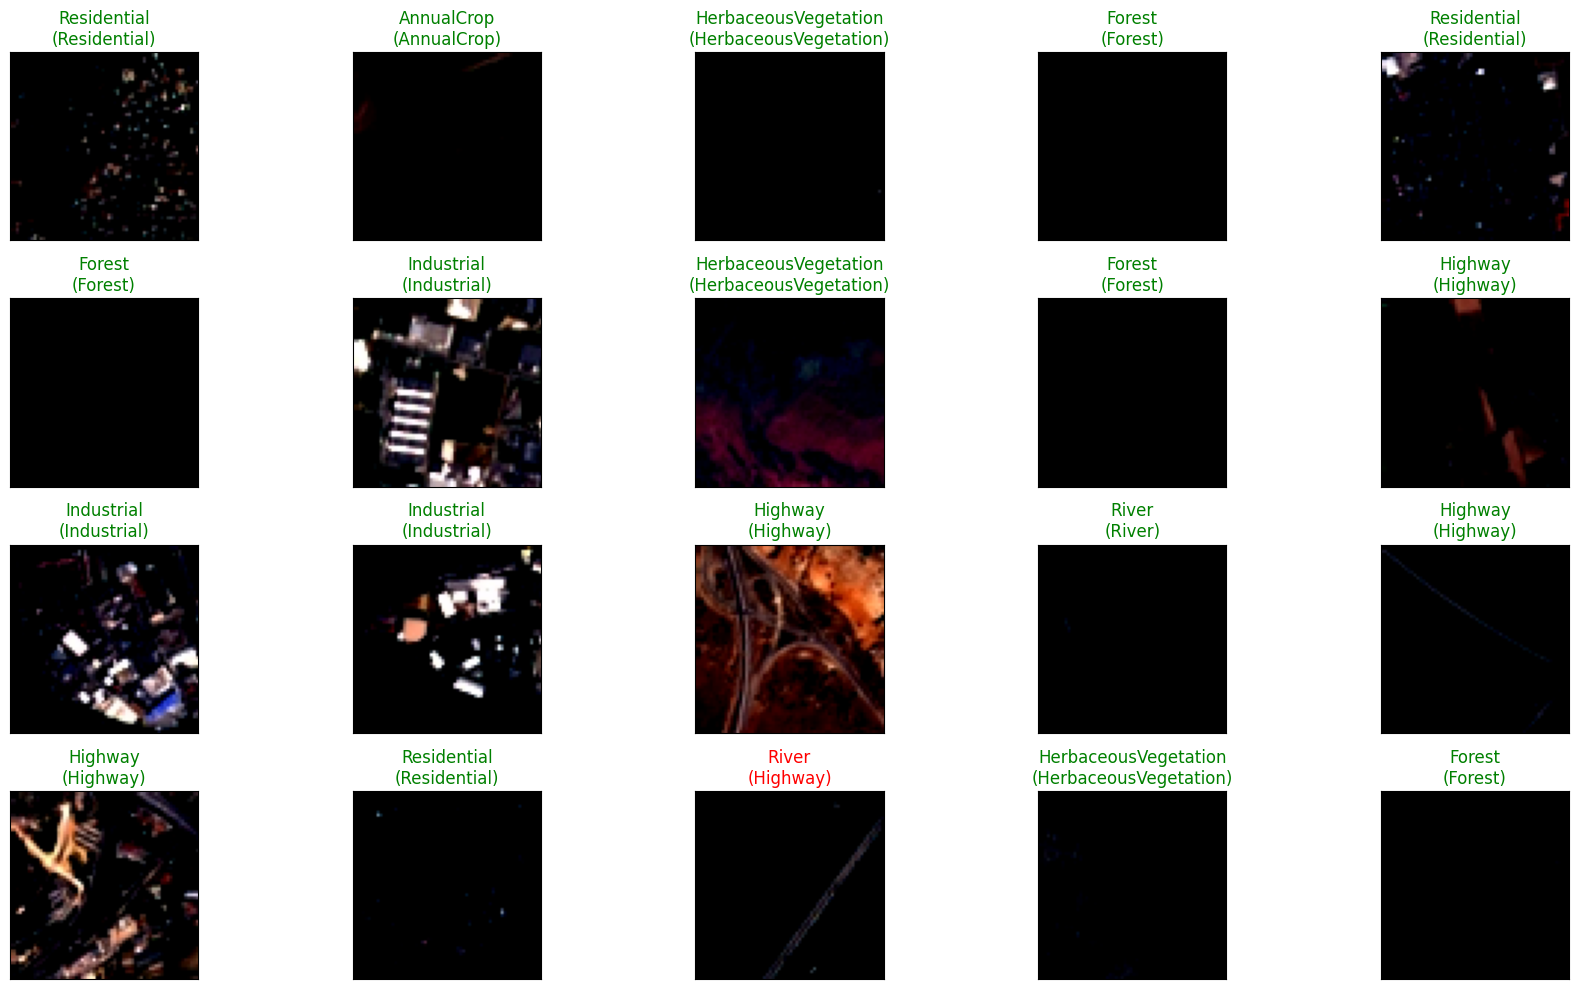

In [ ]:
plot_predictions(true_classes, predictions, test_generator_new, class_indices)

## 8. Save the Model

Persist the fine-tuned model for later reuse or comparison against the other architectures.

In [ ]:
resnet152V2_model.save(os.path.join(DRIVE_SAVE_DIR, 'ResNet152V2_eurosat.keras'))
np.save(os.path.join(DRIVE_SAVE_DIR, 'class_indices.npy'), train_generator.class_indices)